In [187]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import GRU, Dense, Input, Dropout

import random
random.seed(2505)

In [188]:
# Daily Data on Gold.
gold = yf.download('GC=F', start='2020-01-01', end='2026-03-19', interval='1d')

[*********************100%***********************]  1 of 1 completed


In [189]:
gold

Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214
2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107
2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416
2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47
2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236
...,...,...,...,...,...
2026-03-12,5115.799805,5137.200195,5115.799805,5137.200195,410
2026-03-13,5052.500000,5117.000000,5009.500000,5089.600098,479


In [190]:
gold.columns = [col[0] if isinstance(col, tuple) else col for col in gold.columns]

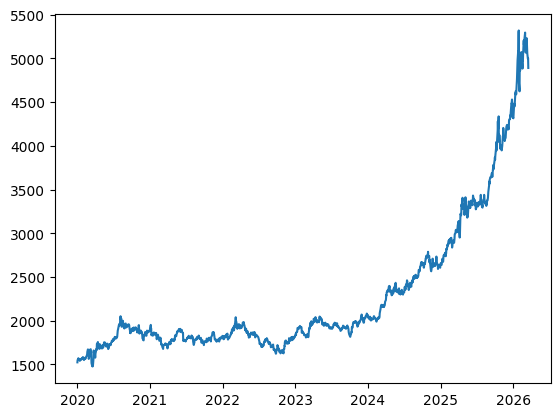

In [191]:
plt.plot(gold['Close'])

In [192]:
returns = gold['Close'].pct_change() # Used for univariate example.

column_names = gold.columns
x = gold.values #returns a numpy array
min_max_scaler = MinMaxScaler()
x_scaled = min_max_scaler.fit_transform(x)
df = pd.DataFrame(x_scaled)

In [193]:
pct_c_gold = df
pct_c_gold.columns = column_names
pct_c_gold

,Close,High,Low,Open,Volume
0,0.012288,0.010897,0.017119,0.012366,0.000852
1,0.018719,0.016747,0.020262,0.015406,0.000426
2,0.023144,0.023402,0.028134,0.028051,0.001656
3,0.024602,0.022500,0.027588,0.022552,0.000187
4,0.020853,0.029301,0.026029,0.027975,0.000939
...,...,...,...,...,...
1557,0.947255,0.890547,0.951734,0.929429,0.001632
1558,0.930775,0.885622,0.924120,0.917368,0.001906
1559,0.915545,0.859685,0.920093,0.895069,0.000517
1560,0.917367,0.861391,0.920146,0.899123,0.000951


### Univariate Forecasting (GRU)

In [194]:
returns

Date
2020-01-02         NaN
2020-01-03    0.016202
2020-01-06    0.010973
2020-01-07    0.003576
2020-01-08   -0.009161
                ...   
2026-03-12   -0.009986
2026-03-13   -0.012373
2026-03-16   -0.011578
2026-03-17    0.001402
2026-03-18   -0.022216
Name: Close, Length: 1562, dtype: float64

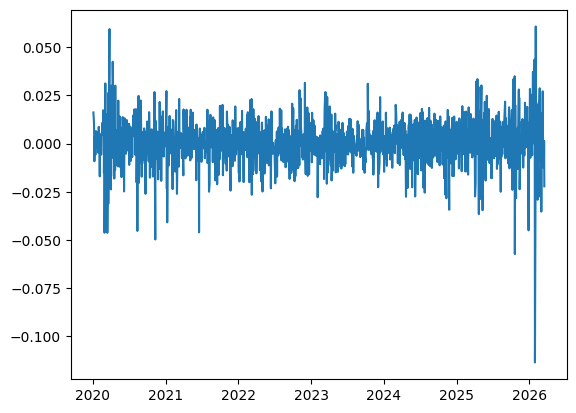

In [195]:
plt.plot(returns)

<Axes: >

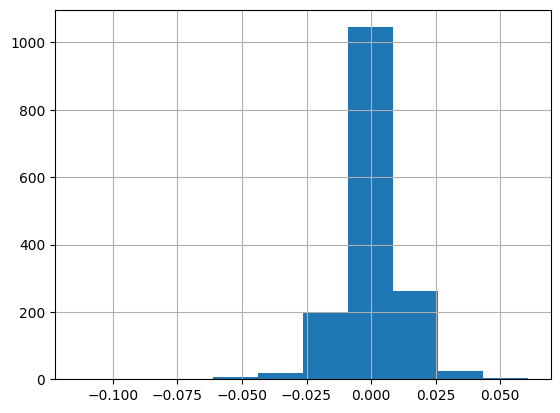

In [196]:
returns.hist()

In [197]:
# Flatten this matrix down.
npa = returns.values[1:].reshape(-1,1) # Python is smart to recognize whatever dimension you need by using this parameter
print(len(npa))
# # Let's scale the data -- this helps avoid the exploding gradient issue
threshold = round(0.9 * len(npa))
scale = MinMaxScaler(feature_range=(0, 1))
npa[:threshold] = scale.fit_transform(npa[:threshold])   # fit on train only
npa[threshold:] = scale.transform(npa[threshold:])       # transform test only
npa

1561


array([[0.60394366],
       [0.55609077],
       [0.4883849 ],
       ...,
       [0.34969301],
       [0.46848891],
       [0.25234021]])

In [198]:
# Need the data to be in the form [sample, time steps, features (dimension of each element)]
samples = 10 # Number of samples (in past)
steps = 1 # Number of steps (in future)
X = [] # X array
Y = [] # Y array
for i in range(npa.shape[0] - samples):
    X.append(npa[i:i+samples]) # Independent Samples
    Y.append(npa[i+samples][0]) # Dependent Samples
print('Training Data: Length is ',len(X[0:1][0]),': ', X[0:1])
print('Testing Data: Length is ', len(Y[0:1]),': ', Y[0:1])

Training Data: Length is  10 :  [array([[0.60394366],
       [0.55609077],
       [0.4883849 ],
       [0.37181321],
       [0.4221637 ],
       [0.48987003],
       [0.40218741],
       [0.42019622],
       [0.51321718],
       [0.43738112]])]
Testing Data: Length is  1 :  [np.float64(0.5135633630766343)]


In [199]:
#Reshape the data so that the inputs will be acceptable to the model.
X = np.array(X)
Y = np.array(Y)
print('Dimensions of X', X.shape, 'Dimensions of Y', Y.shape)

threshold = round(0.9 * X.shape[0])
print('Threshold is', threshold)

Dimensions of X (1551, 10, 1) Dimensions of Y (1551,)
Threshold is 1396


In [200]:
model = keras.Sequential([
    Input(shape=(X.shape[1], X.shape[2])),
    GRU(3, activation = "tanh", recurrent_activation = "sigmoid"),
    Dropout(rate=0.2),
    Dense(1)
])
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_10 (GRU)                    │ (None, 3)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58 (232.00 B)

 Trainable params: 58 (232.00 B)

 Non-trainable params: 0 (0.00 B)

In [201]:
model.compile(loss='mean_squared_error', optimizer = 'adam')

In [202]:
history = model.fit(
    X[:threshold],
    Y[:threshold],
    shuffle = False, # Since this is time series data
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
) # Verbose outputs data

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2516 - val_loss: 0.1614
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1394 - val_loss: 0.0859
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0776 - val_loss: 0.0432
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0459 - val_loss: 0.0227
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0321 - val_loss: 0.0155
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0282 - val_loss: 0.0137
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0265 - val_loss: 0.0130
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0272 - val_loss: 0.0126
Epoch 9/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0255 - val_loss: 0.0127
Epoch 10/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0242 - val_loss: 0.0128
Epoch 11/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0260 - val_loss: 0.0124
Epoch 12/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0

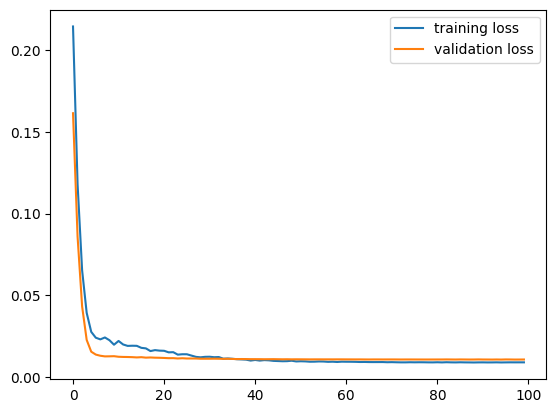

In [203]:
plt.plot(history.history['loss'], label = 'training loss')
plt.plot(history.history['val_loss'], label ='validation loss')
plt.legend()

In [204]:
# Predictions using the 'sliding/rolling window approach'
# Multi step forecast.
# Using self predictions for making future predictions
print(threshold)
true_Y = Y[threshold:]
pred_Y = []
print('Number of Forecasts to do: ',Y.shape[0] - round(Y.shape[0]*0.9))
latest_input = X[threshold - 1:threshold].reshape(samples,)

n_forecasts = Y.shape[0] - round(Y.shape[0] * 0.9)
for i in range(n_forecasts):
    p = model.predict(latest_input.reshape(1, samples, 1))[0, 0]
    pred_Y.append(p)
    latest_input = np.append(latest_input[1:], p)  # true sliding window

1396
Number of Forecasts to do:  155
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/ste

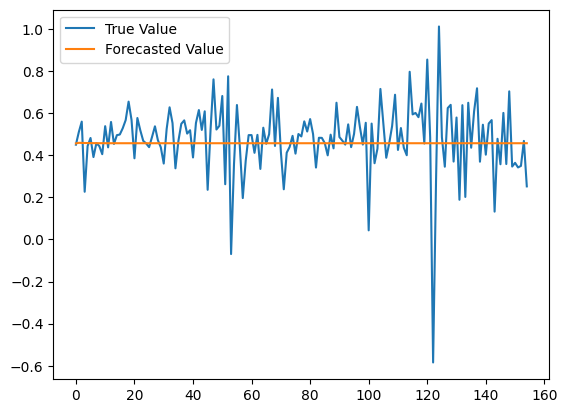

In [205]:
plt.plot(true_Y, label = 'True Value')
plt.plot(pred_Y, label = 'Forecasted Value')
plt.legend()
# Model just copied the same value over and over again. Hence, model is not very robust.
# It's just predicting the mean.

## Multi-Variate Forecasting
### Using our Training and Testing sets, Let's create our inputs.

In [206]:
# Need the data to be in the form [sample, time steps, features (dimension of each element)]
samples = 10 # Number of samples (in past)
steps = 1 # Number of steps (in future)
X = [] # X array
Y = [] # Y array
for i in range(pct_c_gold.shape[0] - samples):
    X.append(pct_c_gold.iloc[i:i+samples, 0:4].values) # Independent Samples
    Y.append(pct_c_gold.iloc[i+samples, 4:].values) # Dependent Samples
print('Training Data: Length is ',len(X[0:1][0]),': ', X[0:1])
print('Testing Data: Length is ', len(Y[0:1]),': ', Y[0:1])

Training Data: Length is  10 :  [array([[0.01228813, 0.01089658, 0.01711911, 0.01236568],
       [0.01871857, 0.0167471 , 0.02026237, 0.01540643],
       [0.02314439, 0.02340208, 0.02813354, 0.02805087],
       [0.02460233, 0.02250013, 0.02758802, 0.0225522 ],
       [0.0208534 , 0.02930134, 0.02602937, 0.02797484],
       [0.01936943, 0.01747841, 0.02369141, 0.02189335],
       [0.02087942, 0.01823413, 0.02423693, 0.02075307],
       [0.01851032, 0.0180391 , 0.02501625, 0.02232414],
       [0.01694826, 0.01528447, 0.0215093 , 0.01961279],
       [0.01947357, 0.01703964, 0.02428887, 0.01994221]])]
Testing Data: Length is  1 :  [array([0.00039001])]


In [207]:
#Reshape the data so that the inputs will be acceptable to the model.
X = np.array(X)
Y = np.array(Y)
print('Dimensions of X', X.shape, 'Dimensions of Y', Y.shape)

Dimensions of X (1552, 10, 4) Dimensions of Y (1552, 1)


In [208]:
# # Get the training and testing set
threshold = round(0.9 * X.shape[0])
trainX, trainY = X[:threshold], Y[:threshold]
testX, testY =  X[threshold:], Y[threshold:]
print('Training Length',trainX.shape, trainY.shape,'Testing Length:',testX.shape, testY.shape)

Training Length (1397, 10, 4) (1397, 1) Testing Length: (155, 10, 4) (155, 1)


In [209]:
model = keras.Sequential([
    Input(shape=(X.shape[1], X.shape[2])),
    GRU(15, activation = "tanh", recurrent_activation = "sigmoid"),
    Dropout(rate=0.2),
    Dense(1)
])
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_11 (GRU)                    │ (None, 15)             │           945 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

In [210]:
model.compile(loss='mean_squared_error', optimizer='adam')

In [211]:
history = model.fit(
    trainX,
    trainY,
    shuffle = False,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0126 - val_loss: 0.0144
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0125 - val_loss: 0.0083
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0120 - val_loss: 0.0067
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0119 - val_loss: 0.0064
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0116 - val_loss: 0.0063
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0117 - val_loss: 0.0063
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0116 - val_loss: 0.0064
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0116 - val_loss: 0.0064
Epoch 9/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0119 - val_loss: 0.0063
Epoch 10/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0116 - val_loss: 0.0064
Epoch 11/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0116 - val_loss: 0.0064
Epoch 12/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0

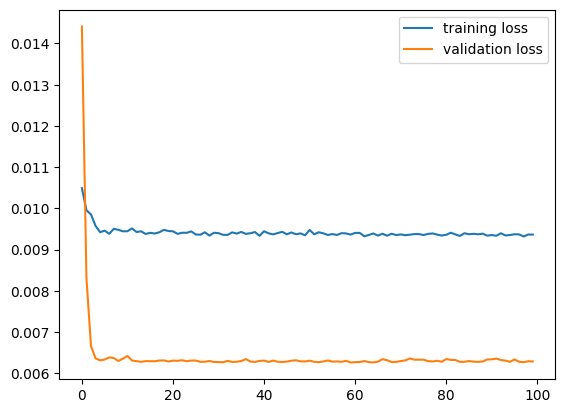

In [212]:
plt.plot(history.history['loss'], label = 'training loss')
plt.plot(history.history['val_loss'], label ='validation loss')
plt.legend()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


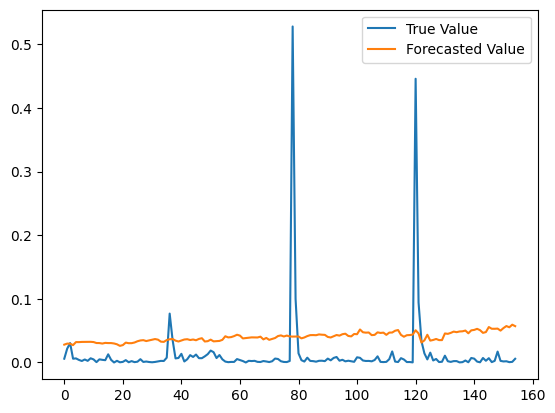

In [213]:
# This is a one step forecast (based on how we constructed our model)
y_pred = model.predict(testX)
plt.plot(testY, label = 'True Value')
plt.plot(y_pred, label = 'Forecasted Value')
plt.legend()